In [ ]:
import os
import polars as pl
from pathlib import Path
from typing import Dict, List, Optional



def load_gtfs_data(gtfs_dir: str = 'simulation/data/IDFM-gtfs') -> Dict[str, pl.DataFrame]:
    """
    Load all GTFS files from directory into Polars DataFrames.

    Args:
        gtfs_dir: Path to directory containing GTFS files

    Returns:
        Dictionary mapping filename (without extension) to DataFrame
    """
    gtfs_path = Path(gtfs_dir)
    print(gtfs_path)
    if not gtfs_path.exists():
        raise FileNotFoundError(f"GTFS directory not found: {gtfs_path}")

    dataframes = {}

    for file_path in gtfs_path.glob('*.txt'):
        try:
            print(file_path)
            # Read CSV file with Polars (handles headers automatically)
            df = pl.read_csv(file_path, encoding='utf-8')
            df.write_csv(str(file_path).replace(".txt" , ".csv"))
            os.remove(file_path)
            # Use filename without extension as key
            table_name = file_path.stem
            dataframes[table_name] = df

            print(f"✅ Loaded {table_name}: {df.shape[0]} rows, {df.shape[1]} columns")

        except Exception as e:
            print(f"❌ Failed to load {file_path.name}: {e}")
            continue

    return dataframes



In [1]:
import polars as pl
import networkx as nx

# 1. (Optional) filter by active service dates:
# calendar = pl.read_csv("calendar.txt")
# calendar_dates = pl.read_csv("calendar_dates.txt")
# build a list of valid service_ids for your target date, then filter trips on that.

# 2. Read the core GTFS files
stops      = pl.read_csv("simulation/data/IDFM-gtfs/stops.csv")
stop_times = pl.read_csv("simulation/data/IDFM-gtfs/stop_times.csv")
trips      = pl.read_csv("simulation/data/IDFM-gtfs/trips.csv")
routes     = pl.read_csv("simulation/data/IDFM-gtfs/routes.csv")
transfers  = pl.read_csv("simulation/data/IDFM-gtfs/transfers.csv")  # if you want transfer edges

# 3. Join stop_times → trips → routes → stops
#    a) stop_times + trips to get route_id on each stop_time
stops_in_trips = (
    stop_times
    .join(trips.select(["trip_id", "route_id", "service_id"]), on="trip_id", how="inner")
    .join(routes.select(["route_id", "route_short_name", "route_type"]), on="route_id", how="left")
    # now you have: trip_id, route_id, route_short_name, route_type, stop_id, stop_sequence, …
    .join(stops.select(["stop_id", "stop_name", "stop_lat", "stop_lon"]), on="stop_id", how="left")
)

# 4. Extract consecutive‐stop edges for each trip
#    We sort by trip_id + stop_sequence, then create “next_stop_id” by shift
edges = (
    stops_in_trips
    .sort(["trip_id", "stop_sequence"])
    .with_columns([
        pl.col("stop_id").shift(-1).over("trip_id").alias("next_stop_id"),
        pl.col("stop_name").shift(-1).over("trip_id").alias("next_stop_name"),
        pl.col("stop_lat").shift(-1).over("trip_id").alias("next_stop_lat"),
        pl.col("stop_lon").shift(-1).over("trip_id").alias("next_stop_lon"),
    ])
    .filter(pl.col("next_stop_id").is_not_null())
    .select([
        "stop_id", "stop_name", "stop_lat", "stop_lon",
        "next_stop_id", "next_stop_name", "next_stop_lat", "next_stop_lon",
        "route_id", "route_short_name"
    ])
).unique()
# 5. (Optional) Extract transfer edges
transfer_edges = (
    transfers
    .select(["from_stop_id", "to_stop_id", "min_transfer_time"])
    .rename({
        "from_stop_id": "stop_id",
        "to_stop_id":   "next_stop_id"
    })
)

# 6. Build a NetworkX graph
G = nx.DiGraph()
# add nodes with position attributes
for row in stops_in_trips.select(["stop_id", "stop_lat", "stop_lon", "stop_name"]).unique().iter_rows():
    stop_id, lat, lon, name = row
    G.add_node(stop_id, x=lon, y=lat, label=name)

# add route‐segment edges
for row in edges.iter_rows():
    sid, _, _, _, nsid, _, _, _, route_id, rname = row
    G.add_edge(sid, nsid, route=route_id, route_name=rname)

# add transfer edges if desired
for row in transfer_edges.iter_rows():
    sid, nsid, mint = row
    G.add_edge(sid, nsid, transfer_time=mint, type="transfer")

G.graph['crs'] = 'EPSG:4326'

In [2]:
len(G.nodes(data=True))

32059

In [3]:
# 1. parse departure_time as seconds‐since‐midnight
with_secs = stops_in_trips.with_columns([
    pl.col("departure_time")
      .str.strptime(pl.Time, format=None ,strict=False)      # parse to Polars Time
      .cast(pl.Int64)                             # convert to integer nanoseconds
      .alias("dep_ns")
]).with_columns([
    # convert nanoseconds → seconds
    (pl.col("dep_ns") / 1e9).cast(pl.Int64).alias("dep_s")
])

# 2. group per stop_id, collect sorted list of seconds
times_per_stop = (
    with_secs
    .group_by("stop_id")
    .agg(
      pl.col("dep_s")
        .sort()
        .unique()                # unique times
        .alias("dep_times_s")    # a List[Int64]
    )
)


In [4]:
# build a dict: stop_id → list of departure times (in seconds)
times_dict = {
  row["stop_id"]: row["dep_times_s"]
  for row in times_per_stop.iter_rows(named=True)
}
for key , value in times_dict.items():
    times_dict[key] = ",".join(map(str , value))

    ...
# then set as a node attribute
nx.set_node_attributes(G, times_dict, name="dep_times_s")


In [5]:
stops_in_trips = stops_in_trips.with_columns([
    pl.col("departure_time")
      .str.strptime(pl.Time, format=None ,strict=False)      # parse to Polars Time
      .cast(pl.Int64)                             # convert to integer nanoseconds
      .alias("dep_ns")
]).with_columns([
    # convert nanoseconds → seconds
    (pl.col("dep_ns") / 1e9).cast(pl.Int64).alias("dep_s")
])

In [6]:
# 1. Compute summary stats in Polars…
stats = (
    stops_in_trips
    .group_by("stop_id")
    .agg([
      pl.col("route_id").n_unique().alias("n_routes"),
      pl.len().alias("n_departures"),
      pl.col("dep_s").min().alias("first_dep_s"),
      pl.col("dep_s").max().alias("last_dep_s"),
    ])
)

# 2. Merge into a dict for networkx
node_attrs = {
    row["stop_id"]: {
        "stop_name": row["stop_name"],
        "zone_id": row.get("zone_id", ""),
        "wheelchair_boarding": int(row.get("wheelchair_boarding", 0)),
        "n_routes": row["n_routes"],
        "n_departures": row["n_departures"],
        "first_dep_s": row["first_dep_s"],
        "last_dep_s": row["last_dep_s"],
        "n_transfers": transfer_edges.filter(pl.col("stop_id")==row["stop_id"]).height,
        "x": float(row["stop_lon"]),
        "y": float(row["stop_lat"]),
    }
    for row in stats.join(stops, on="stop_id").iter_rows(named=True)
}



In [7]:
def clean_attributes_dict(attrs_dict, default_value=""):
    """
    Clean attributes dictionary by replacing None values with default values.

    Parameters:
    attrs_dict: Dictionary of node/edge attributes
    default_value: Value to replace None with (default: empty string)

    Returns:
    Cleaned attributes dictionary
    """
    cleaned_dict = {}
    for node_id, attributes in attrs_dict.items():
        cleaned_attributes = {}
        for key, value in attributes.items():
            if value is None:
                cleaned_attributes[key] = default_value
            else:
                cleaned_attributes[key] = value
        cleaned_dict[node_id] = cleaned_attributes
    return cleaned_dict

def remove_none_from_dict(attrs_dict):
    """
    Remove attributes with None values from the attributes dictionary.

    Parameters:
    attrs_dict: Dictionary of node/edge attributes

    Returns:
    Dictionary with None attributes removed
    """
    cleaned_dict = {}
    for node_id, attributes in attrs_dict.items():
        cleaned_attributes = {k: v for k, v in attributes.items() if v and not isinstance(v , list)}
        cleaned_dict[node_id] = cleaned_attributes
    return cleaned_dict


# 3. Clean the node_attrs dictionary before adding to graph
# Option 1: Replace None with default values
# node_attrs = clean_attributes_dict(node_attrs, default_value="")

# Option 2: Remove None attributes entirely (uncomment to use instead)
node_attrs = remove_none_from_dict(node_attrs)

# 4. Set cleaned attributes on G
nx.set_node_attributes(G, node_attrs)

# 5. Now write to GraphML (should work without issues)
nx.write_graphml(G, "simulation/data/osmnx_layers/IDF_transportation_network.graphml")


In [13]:
import osmnx as ox
import networkx as nx

# Solution 1: Load with error handling and type conversion
def load_graphml_safely(filepath, node_dtypes=None):
    """
    Load GraphML file with better error handling for mixed attribute types
    """
    try:
        # First try the standard approach
        G = ox.io.load_graphml(filepath, node_dtypes=node_dtypes)
        return G
    except AttributeError as e:
        if "'float' object has no attribute 'startswith'" in str(e):
            print("Handling mixed attribute types in GraphML file...")

            # Load using networkx directly (more permissive)
            G = nx.read_graphml(filepath)

            # Convert node dtypes if specified
            if node_dtypes:
                for node_id, data in G.nodes(data=True):
                    for attr, dtype in node_dtypes.items():
                        if attr in data:
                            try:
                                if dtype == str:
                                    data[attr] = str(data[attr])
                                elif dtype == int:
                                    data[attr] = int(float(data[attr]))
                                elif dtype == float:
                                    data[attr] = float(data[attr])
                            except (ValueError, TypeError):
                                pass  # Keep original value if conversion fails

            return G
        else:
            raise e

# Load the graph with safe handling
G_ = load_graphml_safely(
    "./simulation/data/osmnx_layers/IDF_transportation_network.graphml",
    node_dtypes={'osmid': str}
)

print(f"Loaded graph with {len(G_)} nodes and {len(G_.edges)} edges")


Handling mixed attribute types in GraphML file...
Loaded graph with 31877 nodes and 213019 edges


# Graph loaded successfully! You can now proceed with your analysis.


In [10]:
G_.nodes(data=True)['IDFM:11782']

{'x': 2.3376721100808533,
 'y': 48.64418817401462,
 'label': 'Ferdinand Buisson',
 'dep_times_s': 'None,420,1320,20760,22560,23460,23820,24360,25260,25620,26160,26520,27060,27420,27960,28320,28860,29220,29760,30120,30660,31020,31560,31920,32460,32820,33360,33720,34260,34620,35160,35520,36060,36420,36960,37320,37860,38220,38760,39120,39660,40020,40560,40920,41460,41820,42360,42720,43260,43620,44160,44520,45060,45420,45960,46320,46860,47220,47760,48120,48660,49020,49560,49920,50460,50820,51360,51720,52260,52620,53160,53520,54060,54420,54960,55320,55860,56220,56760,57120,57660,58020,58560,58920,59460,59820,60360,60720,61260,61620,62160,62520,63060,63420,63960,64320,64860,65220,65760,66120,66660,67020,67560,67920,68460,68820,69360,69720,70260,70620,71160,71520,72060,72420,72960,73320,73860,74220,74760,75120,75660,76020,76560,76920,77460,77820,78360,78720,79260,79620,80160,80520,81060,81420,81960,82320,82860,83220,83760,84120,84660,85020,85560,85920',
 'stop_name': 'Ferdinand Buisson',
 'zo

In [14]:
nodes_to_remove = [n for n, d in G_.nodes(data=True) if 'x' not in d or 'y' not in d]
print(len(nodes_to_remove))
G_.remove_nodes_from(nodes_to_remove)

0


Graph type: <class 'networkx.classes.multidigraph.MultiDiGraph'>
Is MultiGraph: True


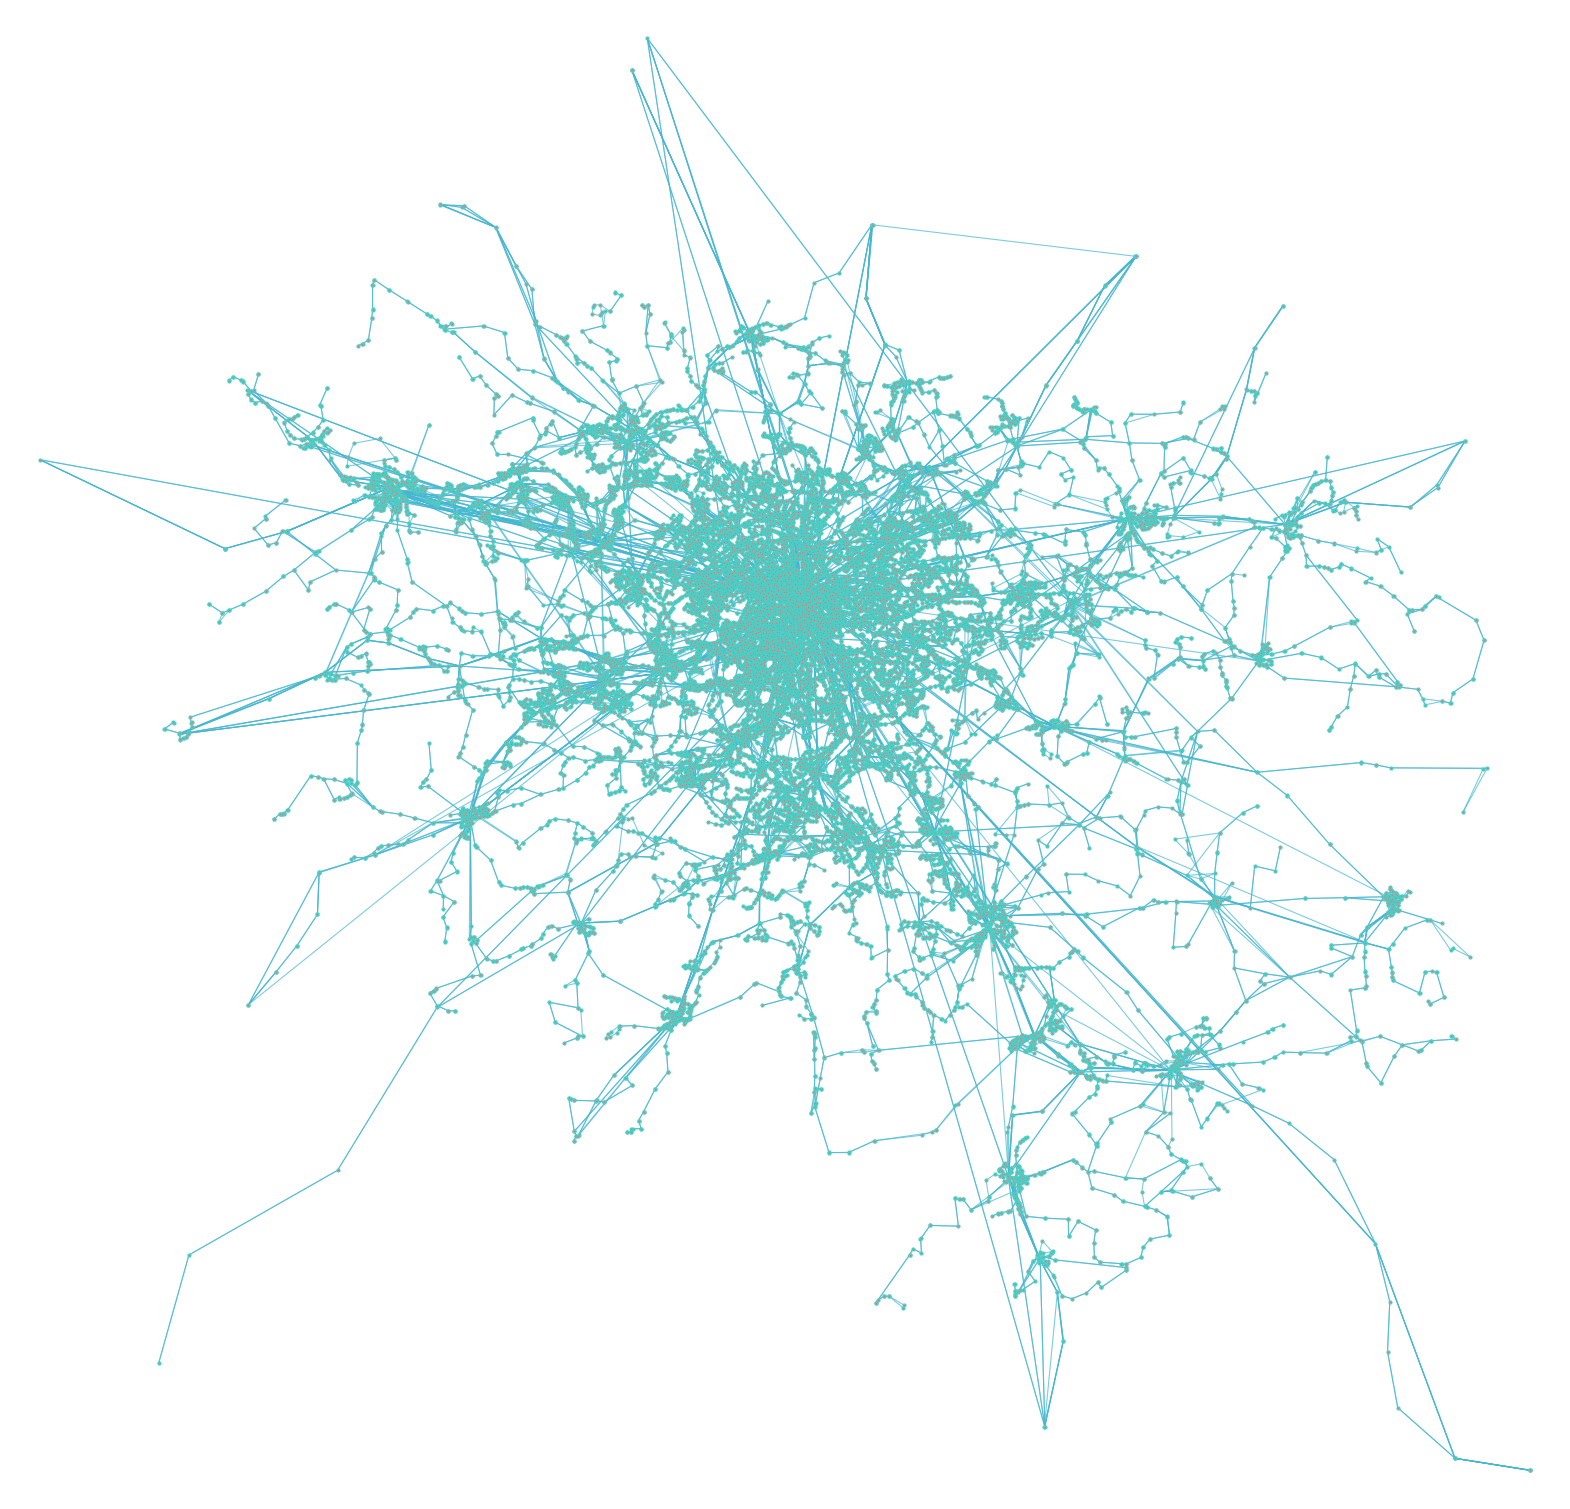

Graph plotted successfully!


In [6]:
import matplotlib.pyplot as plt
import osmnx as ox
import networkx as nx

# Load the graph
# G_ = ox.io.load_graphml("./simulation/data/osmnx_layers/IDF_transportation_network.graphml")

# Check if the graph is a MultiGraph/MultiDiGraph
print(f"Graph type: {type(G_)}")
print(f"Is MultiGraph: {isinstance(G_, (nx.MultiGraph, nx.MultiDiGraph))}")

# Convert to MultiDiGraph if it's not already
if not isinstance(G_, (nx.MultiGraph, nx.MultiDiGraph)):
    print("Converting to MultiDiGraph...")
    if G_.is_directed():
        G_ = nx.MultiDiGraph(G_)
    else:
        G_ = nx.MultiGraph(G_)

# Ensure the graph has the required attributes for OSMnx
# OSMnx expects nodes to have 'x' and 'y' attributes
for node in G_.nodes():
    if 'x' not in G_.nodes[node] or 'y' not in G_.nodes[node]:
        print(f"Warning: Node {node} missing x/y coordinates")

# Now plot the graph
try:
    fig, ax = ox.plot_graph(
        G_,
        figsize=(20, 20),
        bgcolor='#ffffff',                   # Clean white background
        node_color='#ff6b6b',                # Coral red nodes
        node_size=4,
        node_alpha=1.0,                      # Fully opaque nodes
        node_edgecolor='#4ecdc4',            # Teal border
        node_zorder=3,
        edge_color='#45b7d1',                # Sky blue edges
        edge_linewidth=0.8,
        edge_alpha=0.7,
        dpi=800,
        save=True,
        filepath="idf_trans_network.png",
        show=True,
    )
    print("Graph plotted successfully!")
except Exception as e:
    print(f"Error plotting graph: {e}")
    # Alternative: use NetworkX plotting if OSMnx fails
    plt.figure(figsize=(20, 20))
    pos = {node: (G_.nodes[node].get('x', 0), G_.nodes[node].get('y', 0)) for node in G_.nodes()}
    nx.draw(G_, pos, node_color='#ff6b6b', node_size=4, edge_color='#45b7d1', width=0.8)
    plt.savefig("idf_trans_network.png", dpi=800, bbox_inches='tight')
    plt.show()

In [ ]:
import osmnx as ox
import matplotlib.pyplot as plt
import networkx as nx
import nx_cugraph as nxcg
import threading
import concurrent.futures
from typing import Dict, Any, Tuple
import numpy as np

# Load the graph
G = ox.io.load_graphml("./simulation/data/osmnx_layers/IDF_transportation_network.graphml")

def get_node_positions(nodes_data):
    """Thread-safe function to extract node positions from a subset of nodes"""
    return {node: (data['x'], data['y']) for node, data in nodes_data}

def draw_edges_chunk(G, pos, ax, edge_chunk, edge_color='gray', width=0.5, alpha=0.7):
    """Draw a chunk of edges in a separate thread"""
    edge_list = list(edge_chunk)
    nx.draw_networkx_edges(G.subgraph([u for u, v in edge_list] + [v for u, v in edge_list]),
                           pos, ax=ax, edgelist=edge_list,
                           edge_color=edge_color, width=width, alpha=alpha)

def draw_nodes_chunk(G, pos, ax, node_chunk, node_color='red', node_size=10, alpha=0.8):
    """Draw a chunk of nodes in a separate thread"""
    node_list = list(node_chunk)
    node_pos = {node: pos[node] for node in node_list if node in pos}
    nx.draw_networkx_nodes(G, node_pos, ax=ax, nodelist=node_list,
                           node_color=node_color, node_size=node_size, alpha=alpha)

def chunk_data(data, n_chunks):
    """Split data into roughly equal chunks for parallel processing"""
    data_list = list(data)
    chunk_size = len(data_list) // n_chunks + (1 if len(data_list) % n_chunks else 0)
    return [data_list[i:i + chunk_size] for i in range(0, len(data_list), chunk_size)]

def plot_graph_custom_threaded(G, node_color='red', node_size=10, edge_color='gray',
                               bgcolor='white', figsize=(12, 12), n_threads=4):
    """
    Multi-threaded custom graph plotting function
    """
    fig, ax = plt.subplots(figsize=figsize, facecolor=bgcolor)
    ax.set_facecolor(bgcolor)

    # Get node positions using multithreading
    nodes_data = list(G.nodes(data=True))
    node_chunks = chunk_data(nodes_data, n_threads)

    with concurrent.futures.ThreadPoolExecutor(max_workers=n_threads) as executor:
        # Process node positions in parallel
        position_futures = [executor.submit(get_node_positions, chunk) for chunk in node_chunks]
        pos = {}
        for future in concurrent.futures.as_completed(position_futures):
            pos.update(future.result())

    # Draw edges in parallel chunks
    edge_chunks = chunk_data(G.edges(), n_threads)
    with concurrent.futures.ThreadPoolExecutor(max_workers=n_threads) as executor:
        edge_futures = [
            executor.submit(draw_edges_chunk, G, pos, ax, chunk, edge_color, 0.5, 0.7)
            for chunk in edge_chunks
        ]
        # Wait for all edge drawing to complete
        concurrent.futures.wait(edge_futures)

    # Draw nodes in parallel chunks
    node_chunks = chunk_data(G.nodes(), n_threads)
    with concurrent.futures.ThreadPoolExecutor(max_workers=n_threads) as executor:
        node_futures = [
            executor.submit(draw_nodes_chunk, G, pos, ax, chunk, node_color, node_size, 0.8)
            for chunk in node_chunks
        ]
        # Wait for all node drawing to complete
        concurrent.futures.wait(node_futures)

    # Remove axes
    ax.set_axis_off()
    # Set equal aspect ratio
    ax.set_aspect('equal')

    return fig, ax

def alternative_plot_threaded(G, n_threads=4):
    """Alternative threaded plotting approach"""
    fig, ax = plt.subplots(figsize=(12, 12))

    # Get node positions using multithreading
    nodes_data = list(G.nodes(data=True))
    node_chunks = chunk_data(nodes_data, n_threads)

    with concurrent.futures.ThreadPoolExecutor(max_workers=n_threads) as executor:
        position_futures = [executor.submit(get_node_positions, chunk) for chunk in node_chunks]
        node_positions = {}
        for future in concurrent.futures.as_completed(position_futures):
            node_positions.update(future.result())

    # Use networkx draw with the computed positions
    nx.draw(G, pos=node_positions, ax=ax, node_size=10, node_color='red',
            edge_color='gray', width=0.5, with_labels=False)

    ax.set_aspect('equal')
    return fig, ax

# Plot the graph using multi-threaded custom function
print("Starting multi-threaded plotting...")
fig, ax = plot_graph_custom_threaded(G, n_threads=20)
plt.title("Transportation Network (Multi-threaded)")
plt.show()

# Alternative: Try using the threaded basic approach
try:
    print("Trying alternative multi-threaded method...")
    fig, ax = alternative_plot_threaded(G, n_threads=20)
    plt.title("Network Visualization (Multi-threaded)")
    plt.show()

except Exception as e:
    print(f"Alternative threaded method failed: {e}")
    print("The graph data might need to be processed differently.")

Starting multi-threaded plotting...


In [ ]:
# If you need to inspect the graph structure
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Graph type: {type(G)}")

# Check if graph has the expected attributes
if G.nodes():
    sample_node = list(G.nodes(data=True))[0]
    print(f"Sample node data: {sample_node}")

if G.edges():
    sample_edge = list(G.edges(data=True))[0]
    print(f"Sample edge data: {sample_edge}")